=== สรุปผล Background Subtraction ===
Background mean (overall)     : 9.714
Background std (overall)      : 3.470
Residual RMS ก่อน denoise เฉลี่ย : 5.026
Residual RMS หลัง denoise เฉลี่ย : 2.477
เปอร์เซ็นต์ frame ที่ residual > noise floor อย่างน้อย 1 subcarrier : 97.6%
threshold แนะนำสำหรับ activity index : 2.733

บันทึกกราฟที่ ./bg_substraction/csi_human_residual_4.png เรียบร้อย
บันทึกข้อมูล residual (human-only) ที่ ./bg_substraction/csi_human_residual_4.csv เรียบร้อย


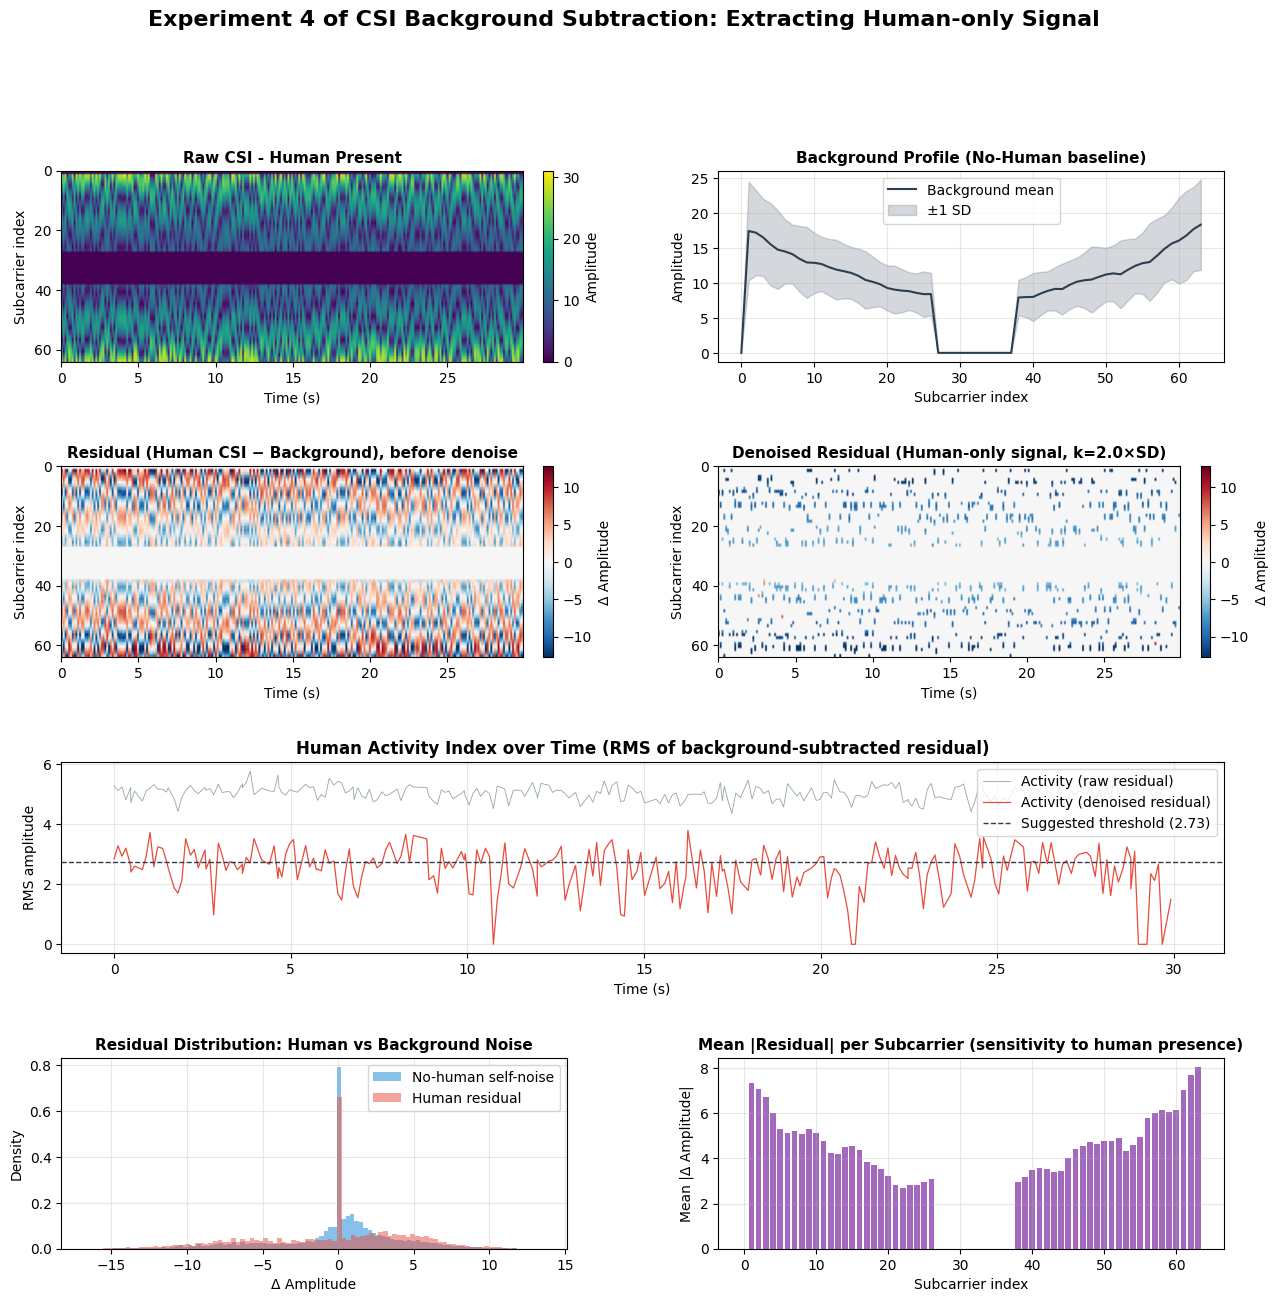

In [4]:
"""
CSI Background Subtraction (Human-only Signal Extraction)
===========================================================
แนวคิด:
  ห้องนอนมีเฟอร์นิเจอร์/กำแพง ซึ่งทำให้เกิด "static multipath" คงที่
  สะท้อนอยู่ใน CSI ตลอดเวลา (background). เราเก็บข้อมูล "ไม่มีคน"
  (CSI_ON_HUMAN.csv) เพื่อใช้เป็น background profile แล้วนำไปลบออกจาก
  ข้อมูล "มีคน" (CSI_HUMAN.csv) frame-ต่อ-frame เพื่อให้เหลือเฉพาะ
  ส่วนที่เกิดจากการเคลื่อนไหว/ร่างกายของคน (residual signal)

ขั้นตอน:
  1. คำนวณ background profile จากค่าเฉลี่ย (mean) และส่วนเบี่ยงเบน
     มาตรฐาน (std) ของแต่ละ subcarrier ในข้อมูล "ไม่มีคน"
  2. Background subtraction: residual = CSI_human - background_mean
  3. Denoise: ค่า residual ที่เล็กกว่า noise floor (k * background_std)
     ถือเป็นสัญญาณรบกวน (noise) ให้ตัดออก (ตั้งเป็น 0)
  4. คำนวณ "Activity Index" = พลังงานของ residual ต่อ frame
     (ใช้บอกว่าช่วงเวลาไหนมีการเคลื่อนไหวมาก/น้อย)
  5. พล็อต heatmap เปรียบเทียบ ก่อน-หลัง subtraction + activity index

Output: bg_subtraction_summary.png
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ---------- 1) โหลดข้อมูล ----------
exp_no = "4";
HUMAN_PATH = f"./experiment/csi_exp{exp_no}_presence.csv"
NOHUMAN_PATH = f"./experiment/csi_exp{exp_no}_absent.csv"
CSI_SAVE_FILENAME_PATH = f"./bg_substraction/csi_human_residual_{exp_no}.csv"
PNG_SAVE_FILENAME_PATH = f"./bg_substraction/csi_human_residual_{exp_no}.png"

df_human = pd.read_csv(HUMAN_PATH)
df_nohuman = pd.read_csv(NOHUMAN_PATH)

sub_cols = [c for c in df_human.columns if c.startswith("Sub_")]
n_sub = len(sub_cols)

for df in (df_human, df_nohuman):
    df["t"] = df["Timestamp"] - df["Timestamp"].iloc[0]

csi_human = df_human[sub_cols].values          # shape (N_human, 64)
csi_nohuman = df_nohuman[sub_cols].values        # shape (N_nohuman, 64)

# ---------- 2) สร้าง Background Profile จากข้อมูล "ไม่มีคน" ----------
bg_mean = csi_nohuman.mean(axis=0)               # ค่าเฉลี่ยพื้นหลัง ต่อ subcarrier (64,)
bg_std = csi_nohuman.std(axis=0)                 # ความผันผวนตามธรรมชาติของพื้นหลัง (64,)

# ---------- 3) Background Subtraction ----------
# ลบพื้นหลังออกจากทุก frame ของข้อมูล "มีคน" (broadcast ตาม subcarrier)
residual_raw = csi_human - bg_mean[np.newaxis, :]        # (N_human, 64)

# ---------- 4) Denoise ด้วย noise floor ----------
# ค่า residual ที่อยู่ในช่วง +-k*std ของพื้นหลัง ถือว่าเป็นความผันผวนปกติ (noise) -> ตัดทิ้ง
K_NOISE = 2.0
noise_floor = K_NOISE * bg_std[np.newaxis, :]
residual_denoised = np.where(np.abs(residual_raw) > noise_floor, residual_raw, 0.0)

# ---------- 5) Activity Index ต่อเวลา (พลังงานของ residual) ----------
activity_raw = np.sqrt(np.mean(residual_raw ** 2, axis=1))          # RMS ต่อ frame (ก่อน denoise)
activity_denoised = np.sqrt(np.mean(residual_denoised ** 2, axis=1))  # RMS ต่อ frame (หลัง denoise)

# threshold แนะนำสำหรับตรวจจับ "คนอยู่ในห้อง/เคลื่อนไหว" จาก percentile ของสัญญาณ denoise
detect_threshold = np.percentile(activity_denoised, 60)

# ---------- 6) สรุปตัวเลข ----------
print("=== สรุปผล Background Subtraction ===")
print(f"Background mean (overall)     : {bg_mean.mean():.3f}")
print(f"Background std (overall)      : {bg_std.mean():.3f}")
print(f"Residual RMS ก่อน denoise เฉลี่ย : {activity_raw.mean():.3f}")
print(f"Residual RMS หลัง denoise เฉลี่ย : {activity_denoised.mean():.3f}")
print(f"เปอร์เซ็นต์ frame ที่ residual "
      f"> noise floor อย่างน้อย 1 subcarrier : "
      f"{100 * np.mean(np.any(residual_denoised != 0, axis=1)):.1f}%")
print(f"threshold แนะนำสำหรับ activity index : {detect_threshold:.3f}")

# ---------- 7) พล็อตกราฟ ----------
fig = plt.figure(figsize=(15, 14))
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.3)

t_human = df_human["t"].values

# (a) Heatmap: raw human CSI
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(csi_human.T, aspect="auto", cmap="viridis",
                  extent=[0, t_human[-1], n_sub, 0])
ax1.set_title("Raw CSI - Human Present", fontsize=11, fontweight="bold")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Subcarrier index")
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label="Amplitude")

# (b) Background profile (mean +- std) as reference
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(n_sub)
ax2.plot(x, bg_mean, color="#2c3e50", label="Background mean")
ax2.fill_between(x, bg_mean - bg_std, bg_mean + bg_std, color="#2c3e50", alpha=0.2,
                  label="±1 SD")
ax2.set_title("Background Profile (No-Human baseline)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Subcarrier index")
ax2.set_ylabel("Amplitude")
ax2.legend()
ax2.grid(alpha=0.3)

# (c) Heatmap: residual before denoise
ax3 = fig.add_subplot(gs[1, 0])
vmax = np.percentile(np.abs(residual_raw), 99)
im3 = ax3.imshow(residual_raw.T, aspect="auto", cmap="RdBu_r",
                  extent=[0, t_human[-1], n_sub, 0], vmin=-vmax, vmax=vmax)
ax3.set_title("Residual (Human CSI − Background), before denoise", fontsize=11, fontweight="bold")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Subcarrier index")
fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04, label="Δ Amplitude")

# (d) Heatmap: residual after denoise (human-only signal)
ax4 = fig.add_subplot(gs[1, 1])
im4 = ax4.imshow(residual_denoised.T, aspect="auto", cmap="RdBu_r",
                  extent=[0, t_human[-1], n_sub, 0], vmin=-vmax, vmax=vmax)
ax4.set_title(f"Denoised Residual (Human-only signal, k={K_NOISE}×SD)",
              fontsize=11, fontweight="bold")
ax4.set_xlabel("Time (s)")
ax4.set_ylabel("Subcarrier index")
fig.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04, label="Δ Amplitude")

# (e) Activity index (RMS of residual) over time
ax5 = fig.add_subplot(gs[2, :])
ax5.plot(t_human, activity_raw, color="#95a5a6", lw=0.6, label="Activity (raw residual)")
ax5.plot(t_human, activity_denoised, color="#e74c3c", lw=0.9, label="Activity (denoised residual)")
ax5.axhline(detect_threshold, color="#2c3e50", ls="--", lw=1,
            label=f"Suggested threshold ({detect_threshold:.2f})")
ax5.set_title("Human Activity Index over Time (RMS of background-subtracted residual)",
              fontsize=12, fontweight="bold")
ax5.set_xlabel("Time (s)")
ax5.set_ylabel("RMS amplitude")
ax5.legend(loc="upper right")
ax5.grid(alpha=0.3)

# (f) Distribution: residual values, human vs background self-noise
ax6 = fig.add_subplot(gs[3, 0])
bg_self_residual = (csi_nohuman - bg_mean[np.newaxis, :]).flatten()
ax6.hist(bg_self_residual, bins=100, alpha=0.6, color="#3498db", density=True,
         label="No-human self-noise")
ax6.hist(residual_raw.flatten(), bins=100, alpha=0.5, color="#e74c3c", density=True,
         label="Human residual")
ax6.set_title("Residual Distribution: Human vs Background Noise", fontsize=11, fontweight="bold")
ax6.set_xlabel("Δ Amplitude")
ax6.set_ylabel("Density")
ax6.legend()
ax6.grid(alpha=0.3)

# (g) Mean |residual| per subcarrier (which subcarriers react most to human presence)
ax7 = fig.add_subplot(gs[3, 1])
mean_abs_residual = np.mean(np.abs(residual_raw), axis=0)
ax7.bar(x, mean_abs_residual, color="#8e44ad", alpha=0.8)
ax7.set_title("Mean |Residual| per Subcarrier (sensitivity to human presence)",
              fontsize=11, fontweight="bold")
ax7.set_xlabel("Subcarrier index")
ax7.set_ylabel("Mean |Δ Amplitude|")
ax7.grid(alpha=0.3)

fig.suptitle(f"Experiment {exp_no} of CSI Background Subtraction: Extracting Human-only Signal",
             fontsize=16, fontweight="bold", y=0.995)

plt.savefig(PNG_SAVE_FILENAME_PATH, dpi=150, bbox_inches="tight")
print(f"\nบันทึกกราฟที่ {PNG_SAVE_FILENAME_PATH} เรียบร้อย")

# ---------- 8) บันทึก residual (human-only) เป็น CSV เผื่อนำไปใช้ต่อ (เช่น train model) ----------
out_df = pd.DataFrame(residual_denoised, columns=sub_cols)
out_df.insert(0, "Timestamp", df_human["Timestamp"].values)
out_df.insert(1, "RSSI", df_human["RSSI"].values)
out_df.insert(2, "ActivityIndex", activity_denoised)
out_df.to_csv(CSI_SAVE_FILENAME_PATH, index=False)
print(f"บันทึกข้อมูล residual (human-only) ที่ {CSI_SAVE_FILENAME_PATH} เรียบร้อย")